In [1]:
from google.colab import files
uploaded = files.upload()

Saving sports-classification.zip to sports-classification.zip


In [2]:
import zipfile
import os

zip_path = "/content/sports-classification.zip"
extract_path = "/content/sports-classification"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


# IMPORT LIBRARIES

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# DIRECTORIES

In [4]:
train_dir = "/content/sports-classification/sports-classification/train"
test_dir = "/content/sports-classification/sports-classification/test"

# PARAMETERS

In [5]:
img_size = (224, 224)
batch_size = 32
num_classes = 100

# IMAGE GENERATORS WITH AUGMENTATION

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

Found 12187 images belonging to 100 classes.
Found 1305 images belonging to 100 classes.
Found 500 images belonging to 100 classes.


# LOAD MOBILENETV2 BASE MODEL

In [7]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# ADD CUSTOM LAYERS

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# COMPILE THE MODEL

In [9]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# TRAIN THE MODEL

In [10]:
model.fit(train_data, validation_data=val_data, epochs=20)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 170s 418ms/step - accuracy: 0.0276 - loss: 5.1164 - val_accuracy: 0.1962 - val_loss: 3.5416
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 146s 384ms/step - accuracy: 0.1445 - loss: 3.7156 - val_accuracy: 0.4199 - val_loss: 2.6697
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 146s 385ms/step - accuracy: 0.3021 - loss: 2.8692 - val_accuracy: 0.5402 - val_loss: 2.1216
Epoch 4/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 147s 386ms/step - accuracy: 0.4249 - loss: 2.3126 - val_accuracy: 0.5954 - val_loss: 1.8135
Epoch 5/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 147s 385ms/step - accuracy: 0.4997 - loss: 1.9853 - val_accuracy: 0.6444 - val_loss: 1.6015
Epoch 6/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 146s 382ms/step - accuracy: 0.5614 - loss: 1.7064 - val_accuracy: 0.6766 - val_loss: 1.4280
Epoch 7/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 147s 385ms/step - accuracy: 0.6052 - loss: 1.5461 - val_accuracy: 0.6835 - val_loss: 1.3334
Epoch 8/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 147s 386ms/step - accuracy: 0.6302 -

# EVALUATE THE MODEL

In [11]:
loss, acc = model.evaluate(test_data)
print(f"TEST ACCURACY: {acc:.2f}")

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8986 - loss: 0.4356
TEST ACCURACY: 0.91


# VISUALIZE TEST IMAGE WITH ACTUAL AND PREDICTED LABELS


INPUT THE TEST IMAGE INDEX YOU WANT TO INSPECT (0–499): 10


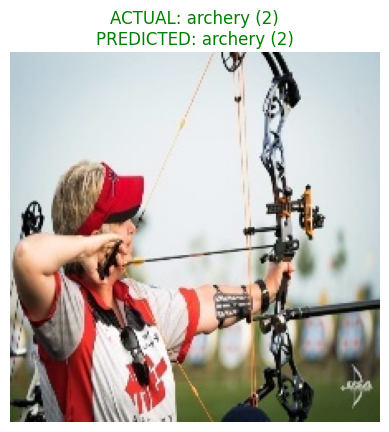

In [23]:
import matplotlib.pyplot as plt
import numpy as np

class_indices = test_data.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

total_images = len(test_data.filenames)

index = int(input(f"INPUT THE TEST IMAGE INDEX YOU WANT TO INSPECT (0–{total_images - 1}): "))

img_batch, label_batch = test_data[index]
img = img_batch[0]
actual_index = np.argmax(label_batch[0])

pred_probs = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
pred_index = np.argmax(pred_probs)

actual_class = index_to_class[actual_index]
predicted_class = index_to_class[pred_index]

plt.imshow(img)
plt.axis("off")
plt.title(f"ACTUAL: {actual_class} ({actual_index})\nPREDICTED: {predicted_class} ({pred_index})",
          color='green' if actual_index == pred_index else 'red')
plt.show()

# DISPLAYING RANDOM TEST IMAGES WITH PREDICTED AND ACTUAL LABELS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


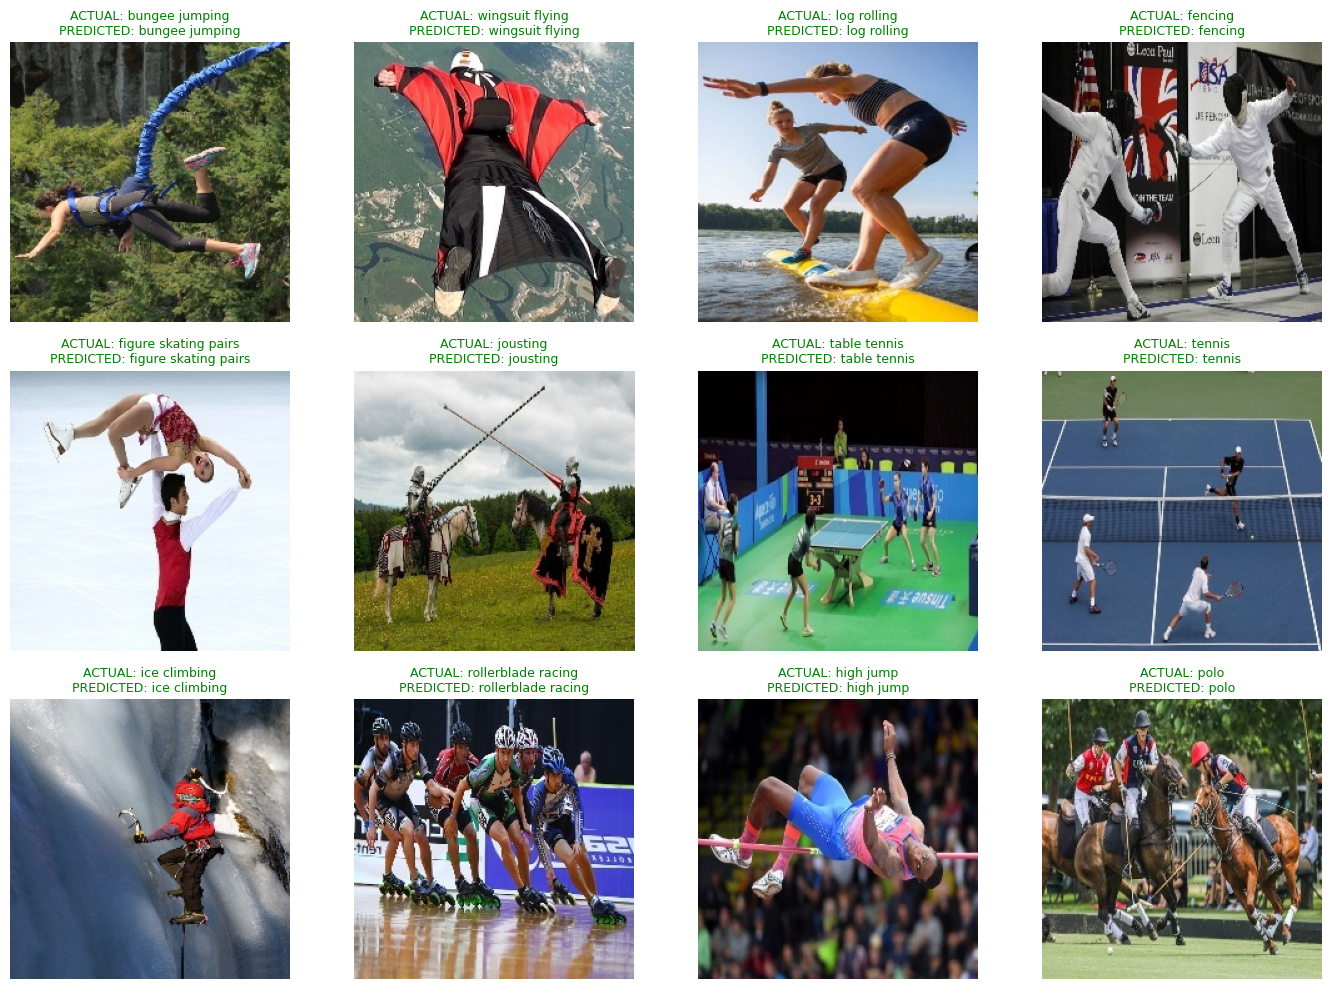

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import random

n = 12
cols = 4
rows = n // cols

class_indices = train_data.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

total_test_images = len(test_data.filenames)
random_indices = random.sample(range(total_test_images), n)

plt.figure(figsize=(14, 10))

for i, idx in enumerate(random_indices):
    img = test_data[idx][0][0]
    actual_index = np.argmax(test_data[idx][1][0])
    pred_probs = model.predict(np.expand_dims(img, axis=0))[0]
    pred_index = np.argmax(pred_probs)

    actual_label = index_to_class[actual_index]
    predicted_label = index_to_class[pred_index]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"ACTUAL: {actual_label}\nPREDICTED: {predicted_label}",
        fontsize=9,
        color='green' if predicted_label == actual_label else 'red'
    )

plt.tight_layout()
plt.show()